## **Weaker and more frequent Mediterranean sea breezes in a warming climate**

Code by: Shalenys Bedoya-Valestt (CIDE, CSIC-UV-GVA)
<br>01 October 2025
<br>Submitted to *Nature Communications*

In [6]:
import numpy as np
import pandas as pd
import xarray as xr
from scipy.stats import linregress
import matplotlib.pyplot as plt

DATA_DIR = '/home/lachale/Documentos/GitHub/BRISES/data/'
START_DATE = "1981-01-01"
END_DATE = "2021-12-31"

# Coordinates
data_coords = pd.read_csv(DATA_DIR + 'ERA5_Points_MED_landsea.csv',  encoding='latin-1', sep=';')
data_coords.loc[data_coords['ID'] == '8416', 'ID'] = '8416Y'

In [7]:
def compute_trends(da, alpha=0.05, decimals=3):
    """Compute linear regression trends per station."""
    out = []
    for st in da.station:
        s = da.sel(station=st).dropna('dates')
        if s.size == 0: continue
        y = s.dates.values
        r = linregress(y, s.values)
        tr = "increasing" if r.pvalue<alpha and r.slope>0 else "decreasing" if r.pvalue<alpha and r.slope<0 else "no trend"
        lab = '***' if r.pvalue<.001 else '**' if r.pvalue<.01 else '*' if r.pvalue<.05 else '.' if r.pvalue<.1 else 'ns'
        out.append([st.item(), tr, round(r.slope*10, decimals), round(r.pvalue,decimals), r.pvalue<alpha, lab])
    return pd.DataFrame(out, columns=['station','trend','slope_decade','p_value','significant','signif_label'])

def compute_regional_trend(da, alpha=0.05, decimals=3):
    """Compute linear trend for a regional mean time series."""
    years = da.dates.values
    res = linregress(years, da.values)
    slope_decade = res.slope * 10
    signif = res.pvalue < alpha
    trend = "increasing" if signif and res.slope > 0 else "decreasing" if signif and res.slope < 0 else "no trend"
    label = '***' if res.pvalue < 0.001 else '**' if res.pvalue < 0.01 else '*' if res.pvalue < 0.05 else '.' if res.pvalue < 0.1 else 'ns'
    return pd.DataFrame([dict(trend=trend, slope_decade=round(slope_decade,decimals), p_value=round(res.pvalue, decimals), significant=signif, signif_label=label)])


countries = ['France','Italy','EI','NA','Spain','BI']
country_index = [['77470','76430','76500','76900','161530'],
    ['161680','162420','162450','162890','163100'],
    ['164290','164050','77650','77800','77610','165600','165460','165200'],
    ['604900','603900','604020','603600','607150'],
    ['6155A','6325O','7031','8025','8019','8416Y','8414A','8500A','9981A','0016A','76','0200E'],
    ['B893','B228','B278','B954']]

### Load Heatwaves list

In [8]:
# Based on ERA5-Land data and identified by using the ctx90pct approximation in the hotspell Python package
hw_list = pd.read_csv(DATA_DIR + 'hws_events_1981_2021.csv', index_col='ID')
hw_metrics = pd.read_csv(DATA_DIR + 'hws_metrics_1981_2021.csv', index_col='ID')

hw_metrics.rename(index={'8416': '8416Y'}, inplace=True)
hw_list.rename(index={'8416': '8416Y'}, inplace=True)

hw_metrics_reset = hw_metrics.reset_index().set_index(['ID', 'year'])  # MultiIndex

# To xarray

station_order = hw_metrics.index.unique()
hw_pivot = hw_metrics.pivot_table(index='year', columns='ID', values='hwn')
hw_pivot = hw_pivot[station_order]

ds_hw = xr.Dataset(
    {"hwn": (("dates", "station"), hw_pivot.values)},
    coords={
        "dates": hw_pivot.index.values,
        "station": hw_pivot.columns.values
    }
)

In [9]:
# ------------------------------------------------------
# -------------- Regional-scale
# ------------------------------------------------------

ds_hw_regional = ds_hw.mean(dim="station")
regional_trends_hw = compute_regional_trend(ds_hw_regional['hwn'], decimals=2)

# ------------------------------------------------------
# -------------- Station-scale
# ------------------------------------------------------

spatial_trends_hw = compute_trends(ds_hw['hwn'], decimals=2)

# ------------------------------------------------------
# -------------- Coastal-scale 
# ------------------------------------------------------

coast_groups = dict(zip(countries, country_index))

# Station averages per coast
ds_hw_coasts = xr.concat(
    [ds_hw.sel(station=[s for s in st if s in ds_hw.station]).mean("station")
     for st in coast_groups.values()], dim="station").assign_coords(station=list(coast_groups.keys()))
coastal_trends_hw = compute_trends(ds_hw_coasts['hwn'], decimals=2)


/tmp/ipykernel_18462/2238283213.py:24: UserWarning: FixedFormatter should only be used together with FixedLocator
  axs.set_xticklabels(years)


Text(0.5, 0.98, 'Number of heatwaves')

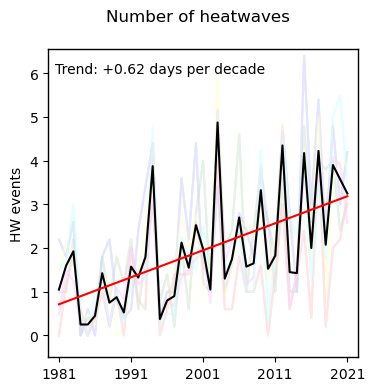

In [21]:
plt.rc("axes",linewidth=1)

fig, axs = plt.subplots(1, 1, sharex='col', sharey=True,figsize=(4,4))
fig.subplots_adjust(hspace=0.04, wspace=0.1)

# Plot
colors = ['green','blue','yellow','red','magenta','cyan']
AUX = ds_hw_coasts.to_dataframe()['hwn']
years = pd.date_range(start='1981',end='2022',freq='Y').year
for j in range(len(countries)):
    plt.plot(years, AUX.loc[countries[j]], c=colors[j],alpha=0.2)
    plt.plot(years, AUX.loc[countries[j]], c='white',alpha=0.5)

plt.plot(years,ds_hw_regional.to_dataframe()['hwn'],c='k')

#calculate equation for trendline
z = np.polyfit(years, ds_hw_regional.to_dataframe()['hwn'], 1)
p = np.poly1d(z)
trend_val = regional_trends_hw['slope_decade'][0]
axs.text(1980.5, 6, "Trend: "+f"{trend_val:+.2f}"+" days per decade", fontsize=10, color='black')

#add trendline to plot
plt.plot(years, p(years), 'red',ls='-')
axs.set_xticklabels(years)
axs.set_xticks([1981,1991,2001,2011,2021])
axs.set_xticklabels([1981,1991,2001,2011,2021])
axs.set_xlim([1979.5,2022.5])
axs.set_ylim([-0.5,6.55])
axs.set_ylabel('HW events')
fig.suptitle('Number of heatwaves')

### SBs occurrence

In [10]:
# Load SBs days during heatwaves
df_sb_hw = pd.read_csv(DATA_DIR + 'SBs_days_heatwaves.csv',index_col=[0], parse_dates=True)

coast_groups = dict(zip(countries, country_index))


# Convert to xarray Dataset
ds_sb_hw = xr.Dataset(
    {"days": (("dates","station"), df_sb_hw.values)},
    coords={"dates": df_sb_hw.index, "station": df_sb_hw.columns}
)

# Regional average
ds_sb_hw_regional_year = ds_sb_hw.mean(dim="station").resample(dates='Y').sum(skipna=True)
ds_sb_hw_regional_year= ds_sb_hw_regional_year.assign_coords(dates=ds_sb_hw_regional_year['dates'].dt.year)

# Station averages per coast
ds_sb_hw_coasts = xr.concat(
    [ds_sb_hw.sel(station=[s for s in st if s in ds_sb_hw.station]).mean("station",skipna=True)
     for st in coast_groups.values()], dim="station").assign_coords(station=list(coast_groups.keys()))
ds_sb_hw_coasts_year = ds_sb_hw_coasts.resample(dates='Y').sum(skipna=True)
ds_sb_hw_coasts_year= ds_sb_hw_coasts_year.assign_coords(dates=ds_sb_hw_coasts_year['dates'].dt.year)

# Trends
regional_trends_sb_hw = compute_regional_trend(ds_sb_hw_regional_year['days'], decimals=2)
coastal_trends_sb_hw = compute_trends(ds_sb_hw_coasts_year['days'], decimals=2)

In [13]:
df_sb_hw.sum()

77470     109.0
76430     168.0
76500     179.0
76900     126.0
161530    107.0
161580    400.0
161680    341.0
162420    426.0
162450    379.0
162890    302.0
163100    417.0
164290    358.0
164050     64.0
77650     369.0
77800     295.0
77610     366.0
165600    389.0
165460    407.0
165200     15.0
604900      8.0
603900     17.0
604020     28.0
603600    129.0
607150    133.0
6155A     126.0
6325O     215.0
7031      145.0
8025      247.0
8019      164.0
8416Y     196.0
8414A     142.0
8500A     149.0
9981A     250.0
0016A     191.0
76        289.0
0200E     431.0
B893      378.0
B228      338.0
B278      330.0
dtype: float64

/tmp/ipykernel_18462/392947746.py:25: UserWarning: FixedFormatter should only be used together with FixedLocator
  axs.set_xticklabels(years)


Text(0.5, 0.98, 'Number of SBs days during heatwaves')

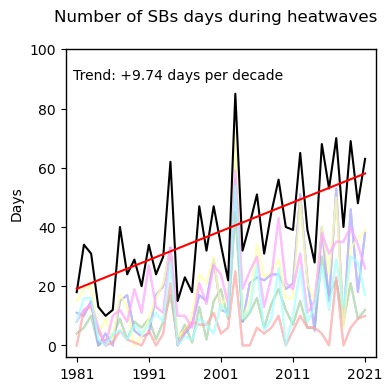

In [7]:
plt.rc("axes",linewidth=1)

fig, axs = plt.subplots(1, 1, sharex='col', sharey=True,figsize=(4,4))
fig.subplots_adjust(hspace=0.04, wspace=0.1)

# Plot
colors = ['green','blue','yellow','red','magenta','cyan']

years = pd.date_range(start='1981',end='2022',freq='Y').year
for j in range(len(list(coast_groups.keys()))):
    AUX = ds_sb_hw_coasts_year.sel(station=list(coast_groups.keys())[j],drop=True).to_dataframe()
    plt.plot(years, AUX, c=colors[j],alpha=0.5)
    plt.plot(years, AUX, c='white',alpha=0.5)

regional_ds = ds_sb_hw_regional_year.to_dataframe()
plt.plot(years,regional_ds,c='k')
#calculate equation for trendline
z = np.polyfit(years, regional_ds['days'], 1)
p = np.poly1d(z)
trend_val = regional_trends_sb_hw['slope_decade'][0]
axs.text(1980.5, 90, "Trend: "+f"{trend_val:+.2f}"+" days per decade", fontsize=10, color='black')

#add trendline to plot
plt.plot(years, p(years), 'red',ls='-')
axs.set_xticklabels(years)
axs.set_xticks([1981,1991,2001,2011,2021])
axs.set_xticklabels([1981,1991,2001,2011,2021])
axs.set_xlim([1979.5,2022.5])
axs.set_ylim([-4,100])
axs.set_ylabel('Days')
fig.suptitle('Number of SBs days during heatwaves')

### SBs speeds

In [14]:
# Load SBs speeds summer dataset
df_speeds_summer = pd.read_csv(DATA_DIR + 'Summer_SBs_speeds.csv')

In [17]:
aux=df_speeds_summer.set_index(['dates','heatwave','station'])

In [22]:
aux.loc[:,'hw','8416Y',:].count()

ws    196
dtype: int64

In [319]:
import pingouin as pg
from statsmodels.stats.multitest import multipletests
import pandas as pd

# Function to compute summary per station
def compute_station_summary(df):
    summary = df.groupby('station').apply(
        lambda x: pd.Series({
            'hw': x.loc[x['heatwave']=='hw','ws'].mean(),
            'nhw': x.loc[x['heatwave']=='nhw','ws'].mean(),
            'std_hw': x.loc[x['heatwave']=='hw','ws'].sem(),
            'std_nhw': x.loc[x['heatwave']=='nhw','ws'].sem(),
            'mean': x['ws'].mean()
        })
    )
    return summary

def compute_percentage_change(df):
    """Compute percent change from non-HW to HW."""
    return ((df['hw'] - df['nhw'])/df['mean'])*100

def compute_ttests(df):
    results = []
    for station, subdf in df.groupby("station"):
        hw_vals = subdf.loc[subdf["heatwave"] == "hw", "ws"].dropna()
        nhw_vals = subdf.loc[subdf["heatwave"] == "nhw", "ws"].dropna()
        t, p = pg.ttest(hw_vals, nhw_vals, paired=False, correction=False)[['T', 'p-val']].iloc[0]
        results.append({'station': station, 't': t, 'p': p})
    res = pd.DataFrame(results)
    res['p_adj'] = multipletests(res['p'], method='holm')[1]
    res['significant'] = res['p_adj'] < 0.05
    return res.set_index('station')


In [334]:
# ------------------------------
# Station-level
# ------------------------------
summary_speeds_summer_station = compute_station_summary(df_speeds_summer)
change = compute_percentage_change(summary_speeds_summer)
t_test_station = compute_ttests(df_speeds_summer)
t_test_station['change %'] = change
# ------------------------------

# ------------------------------
# Coastal-level
# ------------------------------
mapping = {st:c for c, lst in zip(countries, country_index) for st in lst}

df_speeds_summer_coastal = (
    df_speeds_summer.assign(station=df_speeds_summer['station'].map(mapping))
       .groupby(['station','heatwave','dates'])['ws']
       .mean().reset_index()
)
summary_speeds_summer_coastal = compute_station_summary(df_speeds_summer_coastal)
change = compute_percentage_change(summary_speeds_summer_coastal)
t_test_coastal = compute_ttests(df_speeds_summer_coastal)
t_test_coastal['change %'] = change.round(2)

# ------------------------------
# Regional-level
# ------------------------------

hw = df_speeds_summer.loc[df_speeds_summer['heatwave']=='hw','ws']
nhw = df_speeds_summer.loc[df_speeds_summer['heatwave']=='nhw','ws']

summary_summer_regional = pd.Series({
    'hw': hw.mean(),
    'nhw': nhw.mean(),
    'std_hw': hw.sem(),
    'std_nhw': nhw.sem(),
    'mean': df_speeds_summer['ws'].mean(),
    'change %': (hw.mean() - nhw.mean()) / df_speeds_summer['ws'].mean() * 100,
    't': pg.ttest(hw, nhw, paired=False, correction=False)['T'][0],
    'p': pg.ttest(hw, nhw, paired=False, correction=False)['p-val'][0],
})
summary_summer_regional['significant'] = summary_summer_regional['p'] < 0.05
summary_summer_regional = summary_summer_regional

# ------------------------------

In [353]:
# Join dataset for figure
coastal_dataset = pd.concat([summary_speeds_summer_coastal,t_test_coastal],axis=1)

regional_dataset = pd.DataFrame(summary_summer_regional).T
regional_dataset.index = ['Regional']
regional_dataset.index.name = 'station'

global_dataset = pd.concat([regional_dataset, coastal_dataset])

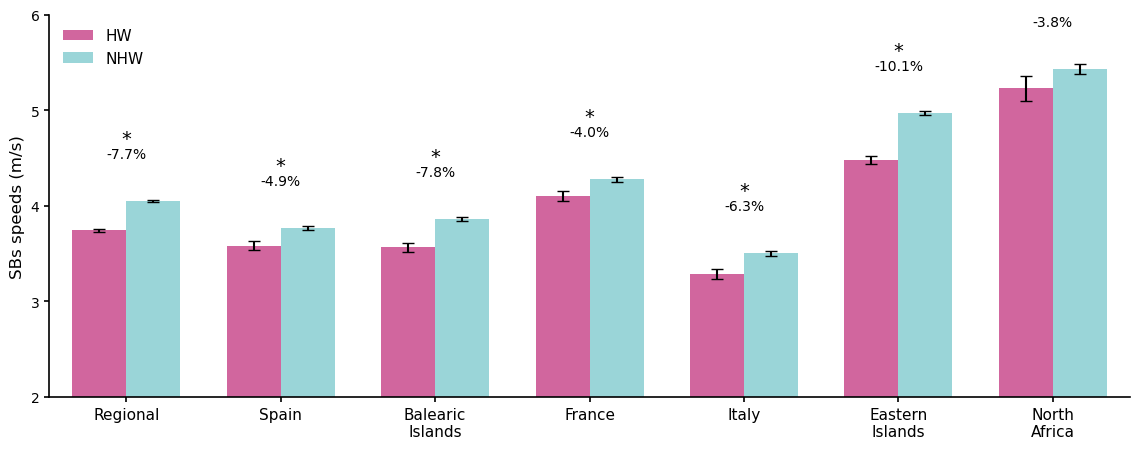

In [377]:
# Reorder regions
regions_order = ['Regional','Spain','BI','France','Italy','EI','NA']
res_plot = global_dataset.reindex(regions_order)

width = 0.35
ind = np.arange(len(res_plot))  # numeric positions for x-axis

fig, ax = plt.subplots(figsize=(11.5,4.6))

# Bars with error bars
ax.bar(ind - width/2, res_plot['hw'], width, yerr=res_plot['std_hw'],
       color='#d1669e', label='HW', capsize=4)
ax.bar(ind + width/2, res_plot['nhw'], width, yerr=res_plot['std_nhw'],
       color='#9ad5d8', label='NHW', capsize=4)

# Box-style axes
ax.set_xlim([-0.5, len(ind)-0.5])
ax.set_xticks(ind)
ax.set_xticklabels(['Regional','Spain','Balearic\nIslands','France','Italy','Eastern\nIslands','North\nAfrica'], fontsize=11)
ax.set_ylabel('SBs speeds (m/s)', fontsize=12)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_linewidth(1.2)
ax.spines['left'].set_linewidth(1.2)
ax.tick_params(width=1.2)
ax.set_ylim([2,6])
ax.set_yticks([2,3,4,5,6])

# Add % change above bars
for i, (_, row) in enumerate(res_plot.iterrows()):
    y = max(row['hw'], row['nhw']) + 0.45
    ax.text(i, y, f"{row['change %']:.1f}%", ha='center', fontsize=10)

# Add significance marker (*)
for i, (_, row) in enumerate(res_plot.iterrows()):
    if row['significant']:
        y = max(row['hw'], row['nhw']) + 0.6
        ax.text(i, y, '*', ha='center', fontsize=14, color='k')

# Legend
ax.legend(frameon=False, fontsize=11)

plt.tight_layout()
plt.show()
fig.savefig('/home/lachale/Documentos/GitHub/BRISES-Nature/scripts/Fig 3/HWS_SBS_speeds.pdf', format='pdf')